# Clustering Comparison — Challenge A

This notebook is the clean entry point for the interface.
It loads one brain, runs all three clustering methods, and produces
a side-by-side UMAP visualisation so the user can pick the best one.

**Three methods:**
| Method | Idea | Extra output |
|---|---|---|
| KMeans | Hard centroid assignment | Inertia, elbow plot |
| Hierarchical | Bottom-up tree (Ward linkage) | Dendrogram |
| GMM | Soft probabilistic assignment | BIC/AIC, per-patch confidence |

## Setup

In [1]:
import sys
sys.path.insert(0, '.')   # repo root so 'src' and 'bucket_access' are importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage

from bucket_access.bucket_utils import list_files, read_h5_embeddings, read_h5_patches
from src.run_clustering import run, sweep_k, ClusteringConfig, Method

## Parameters — change these and re-run all cells

In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────
BRAIN_INDEX = 0           # which brain to load (0–11)

# ── Clustering ────────────────────────────────────────────────────────────────
N_CLUSTERS = 8            # used for all three methods

# Feature blending: mix patch quality stats into the embedding space
METADATA_FEATURES = ['sharpness', 'snr', 'local_contrast', 'mean_intensity', 'foreground_fraction']
METADATA_WEIGHT   = 0.0   # 0 = embeddings only, try 0.2–0.5

# ── UMAP ──────────────────────────────────────────────────────────────────────
UMAP_N_NEIGHBORS = 15     # try 5–50
UMAP_MIN_DIST    = 0.1    # try 0.0–0.3

# ── Method-specific ───────────────────────────────────────────────────────────
KMEANS_INIT          = 'k-means++'   # or 'random'
HIERARCHICAL_LINKAGE = 'ward'        # 'ward' | 'complete' | 'average' | 'single'
GMM_COVARIANCE_TYPE  = 'full'        # 'full' | 'tied' | 'diag' | 'spherical'

RANDOM_STATE = 42
# ──────────────────────────────────────────────────────────────────────────────

# Shared config base (method overridden per run)
BASE = dict(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    metadata_features=METADATA_FEATURES,
    metadata_weight=METADATA_WEIGHT,
    umap_n_neighbors=UMAP_N_NEIGHBORS,
    umap_min_dist=UMAP_MIN_DIST,
    kmeans_init=KMEANS_INIT,
    hierarchical_linkage=HIERARCHICAL_LINKAGE,
    gmm_covariance_type=GMM_COVARIANCE_TYPE,
)

## Load embeddings (used for clustering + UMAP)\n\nAll clustering runs on the precomputed PLIP embeddings — 512-dim vectors, one per patch.\nPatches (raw images) are only loaded later for the representative-patch display.

In [3]:
emb_files   = sorted([k for k in list_files('challengeA/embeddings/') if k.endswith('_embeddings.h5')])
patch_files = sorted([k for k in list_files('challengeA/patches/')    if k.endswith('_patches.h5')])

print(f"{len(emb_files)} embedding files found")

# Load embeddings — ~2 MB per file, fast
emb_key             = emb_files[BRAIN_INDEX]
embeddings, emb_attrs = read_h5_embeddings(emb_key)

scan_name = emb_attrs.get('scan_name', emb_key.split('/')[-1].replace('_embeddings.h5', ''))
condition = emb_attrs.get('condition', '?')

# Load the matching metadata CSV row for this brain's quality stats (sharpness, SNR, etc.)
# Metadata is stored inside the patches H5 but we can read just the metadata without
# loading all ~50 MB of pixel data by using read_h5_patches and discarding the array.
# This is fast because metadata is a small structured array.
_, metadata, patch_attrs = read_h5_patches(patch_files[BRAIN_INDEX])

# patches array is not kept here — only loaded on demand for display (see cell below)
patches = None   # populated later only if you want to view representative images

print(f"Scan     : {scan_name}")
print(f"Condition: {condition}")
print(f"Embeddings: {embeddings.shape}  dtype={embeddings.dtype}  (L2-normalised PLIP, 512-dim)")
print(f"Metadata  : {metadata.shape}  columns: {list(metadata.columns)}")

12 embedding files found
✓ Loaded 573 embeddings from 260219_AN0B2_G002_mouse_brain_MB1_SCAN0_11-56-32_embeddings.h5
✓ Loaded 573 patches from 260219_AN0B2_G002_mouse_brain_MB1_SCAN0_11-56-32_patches.h5
Scan     : 260219_AN0B2_G002_mouse_brain_MB1_SCAN0_11-56-32
Condition: ?
Embeddings: (573, 512)  dtype=float32  (L2-normalised PLIP, 512-dim)
Metadata  : (573, 12)  columns: ['patch_idx', 'z0', 'y0', 'x0', 'z_mid_absolute', 'mean_intensity', 'std_intensity', 'fraction_signal', 'sharpness', 'snr', 'local_contrast', 'foreground_fraction']


## Helper — normalised patch display

In [4]:
def show_patches(patches, indices, titles=None, ncols=8, figsize_per=(1.8, 1.8)):
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * figsize_per[0], nrows * figsize_per[1]))
    axes = np.array(axes).flatten()
    for i, idx in enumerate(indices):
        img = patches[idx].astype(np.float32)
        p2, p98 = np.percentile(img, 2), np.percentile(img, 98)
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        axes[i].imshow(img, cmap='gray', interpolation='nearest')
        axes[i].set_title(titles[i] if titles else str(idx), fontsize=7)
        axes[i].axis('off')
    for ax in axes[len(indices):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Run all three clustering methods

In [5]:
results = {}
coords  = {}

for method in Method:
    cfg = ClusteringConfig(method=method, **BASE)
    result, umap1, umap2, dim = run(embeddings, metadata, cfg)
    results[method] = result
    coords[method]  = (umap1, umap2, dim)

print("\nSilhouette scores:")
for m, r in results.items():
    print(f"  {m.value:<15} {r.silhouette:.4f}")

c:\Users\konst\Documents\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[kmeans]  k=8  silhouette=0.1097  dim_reduction=UMAP


c:\Users\konst\Documents\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[hierarchical]  k=8  silhouette=0.1033  dim_reduction=UMAP


c:\Users\konst\Documents\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[gmm]  k=8  silhouette=0.1168  dim_reduction=UMAP

Silhouette scores:
  kmeans          0.1097
  hierarchical    0.1033
  gmm             0.1168


## Side-by-side UMAP — all three methods

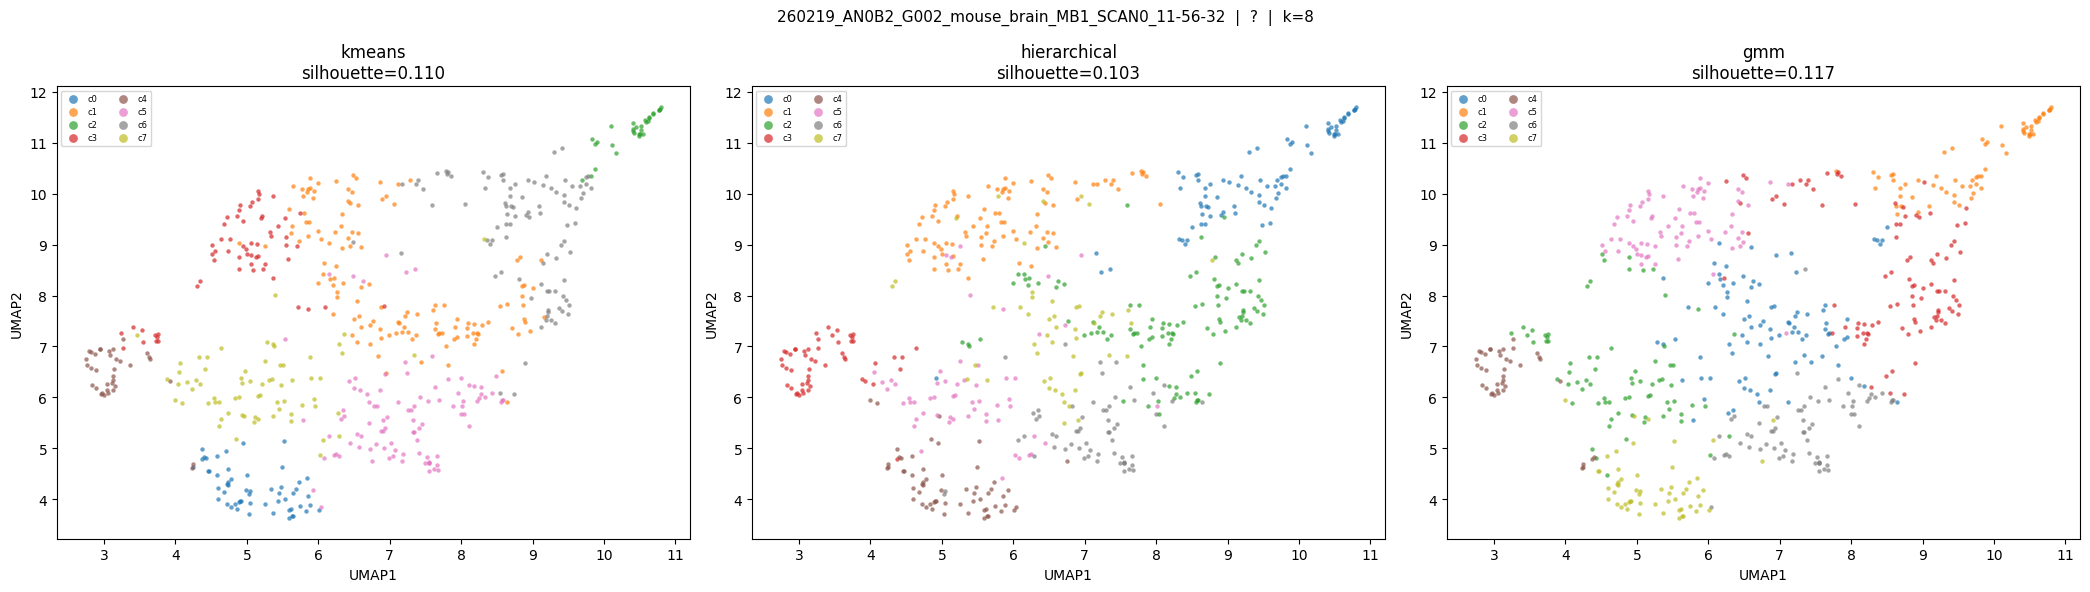

In [6]:
cmap_tab = plt.get_cmap('tab10')
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f"{scan_name}  |  {condition}  |  k={N_CLUSTERS}", fontsize=11)

for ax, method in zip(axes, Method):
    r = results[method]
    u1, u2, dim = coords[method]
    for c in range(N_CLUSTERS):
        mask = r.labels == c
        ax.scatter(u1[mask], u2[mask], s=10, alpha=0.7,
                   color=cmap_tab(c / N_CLUSTERS), label=f"c{c}", linewidths=0)
    ax.set_title(f"{method.value}\nsilhouette={r.silhouette:.3f}")
    ax.set_xlabel(f"{dim}1")
    ax.set_ylabel(f"{dim}2")
    ax.legend(markerscale=2, fontsize=6, ncol=2, loc='best')

plt.tight_layout()
plt.show()

## Silhouette comparison bar chart

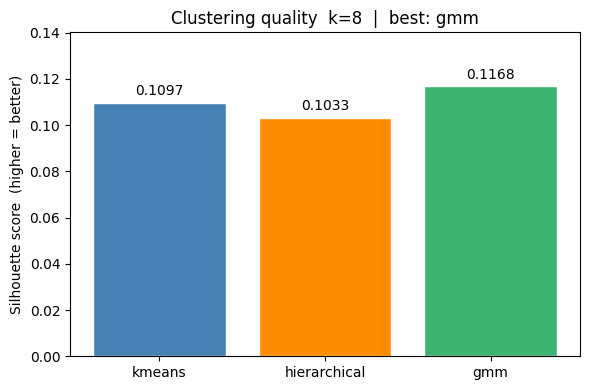

In [7]:
names = [m.value for m in Method]
scores = [results[m].silhouette for m in Method]
colors = ['steelblue', 'darkorange', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(names, scores, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, max(scores) * 1.2)
ax.set_ylabel('Silhouette score  (higher = better)')
ax.set_title(f'Clustering quality  k={N_CLUSTERS}')
best = names[np.argmax(scores)]
ax.set_title(f'Clustering quality  k={N_CLUSTERS}  |  best: {best}')
plt.tight_layout()
plt.show()

## Silhouette sweep (k=2–16) — auto best-k per method

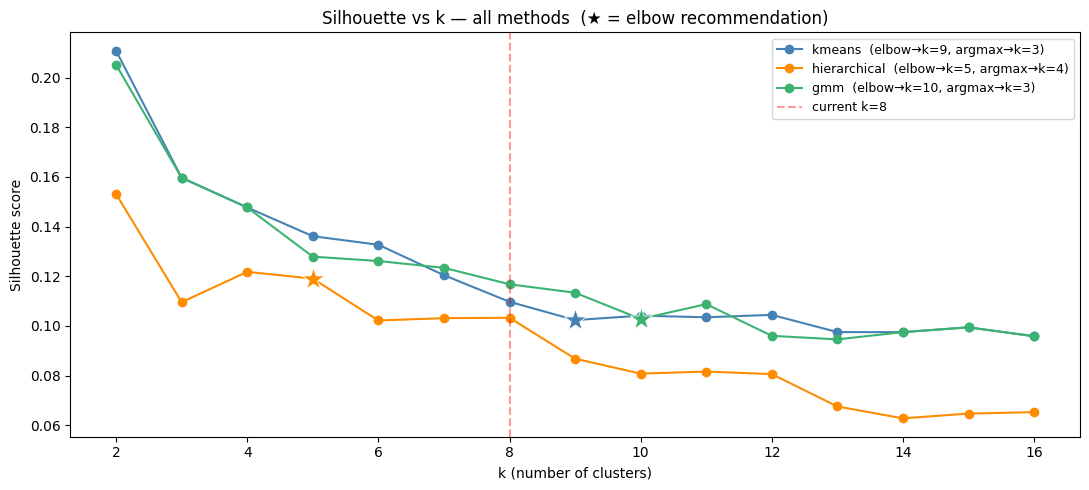


Auto-selected k per method (elbow):
  kmeans          k = 9
  hierarchical    k = 5
  gmm             k = 10


In [8]:
import importlib, src.run_clustering
importlib.reload(src.run_clustering)
from src.run_clustering import find_best_k, sweep_k, ClusteringConfig, Method

colors      = ['steelblue', 'darkorange', 'mediumseagreen']
best_k_per_method = {}   # stored for use in later cells

fig, ax = plt.subplots(figsize=(11, 5))

for method, color in zip(Method, colors):
    cfg   = ClusteringConfig(method=method, **BASE)
    sweep = sweep_k(embeddings, metadata, cfg, k_range=range(2, 17))

    k_elbow, k_argmax = find_best_k(sweep, k_min=3)
    best_k_per_method[method] = k_elbow

    ax.plot(sweep['k'], sweep['silhouette'], 'o-', color=color,
            label=f"{method.value}  (elbow→k={k_elbow}, argmax→k={k_argmax})")

    # Mark the elbow with a filled star
    idx = sweep['k'].index(k_elbow)
    ax.scatter(k_elbow, sweep['silhouette'][idx],
               marker='*', s=280, color=color, zorder=5, edgecolors='white', linewidths=0.6)

ax.axvline(N_CLUSTERS, color='red', linestyle='--', alpha=0.4, label=f'current k={N_CLUSTERS}')
ax.set_xlabel('k (number of clusters)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette vs k — all methods  (★ = elbow recommendation)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nAuto-selected k per method (elbow):")
for m, k in best_k_per_method.items():
    print(f"  {m.value:<15} k = {k}")

## Hierarchical — dendrogram (sample of 200 patches)

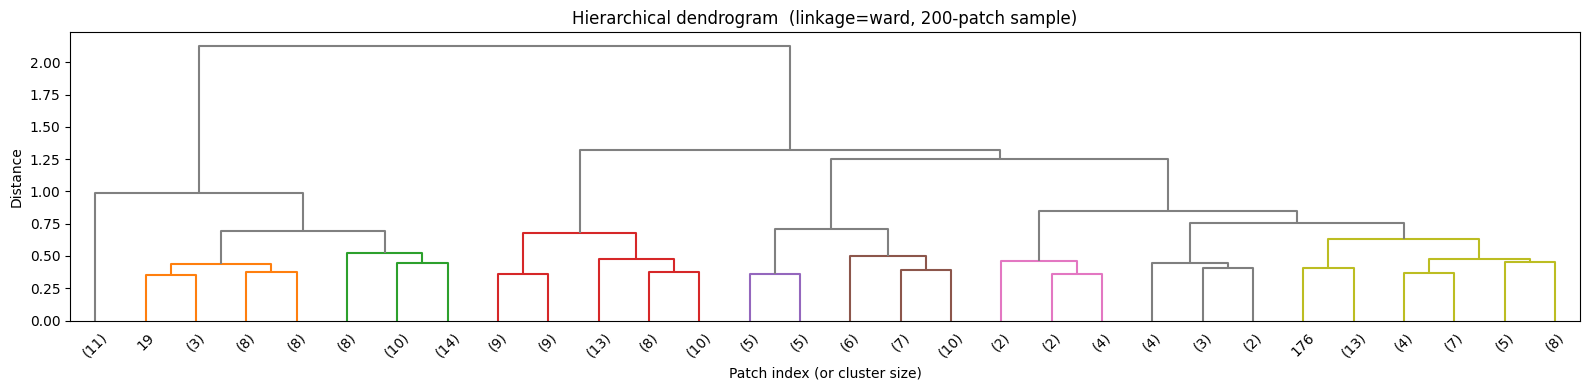

In [9]:
# Subsample for readability — full dendrogram would be unreadable at N=500+
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(embeddings), size=min(200, len(embeddings)), replace=False)
sample_emb = embeddings[sample_idx]

Z = linkage(sample_emb, method=HIERARCHICAL_LINKAGE)

fig, ax = plt.subplots(figsize=(16, 4))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           color_threshold=Z[-N_CLUSTERS, 2], above_threshold_color='grey')
ax.set_title(f'Hierarchical dendrogram  (linkage={HIERARCHICAL_LINKAGE}, 200-patch sample)')
ax.set_xlabel('Patch index (or cluster size)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

## GMM — BIC / AIC sweep

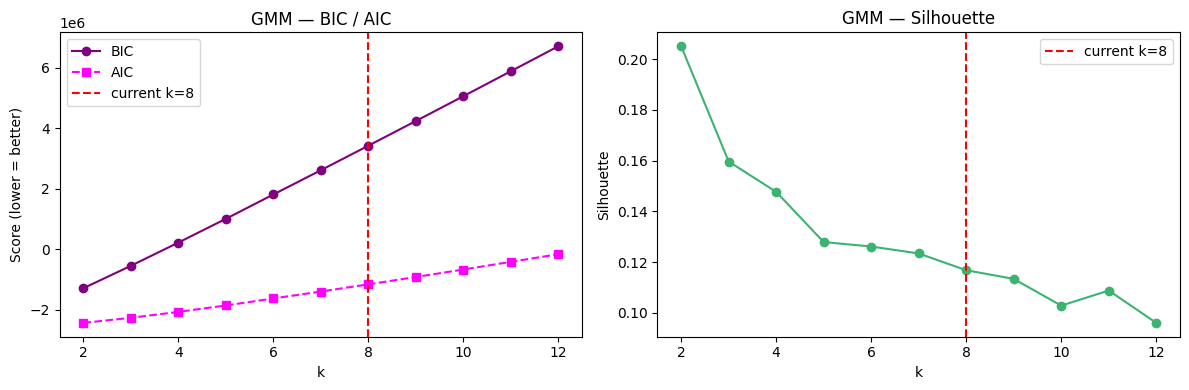

In [10]:
from src.run_clustering import ClusteringConfig, Method
from src import cluster_gmm
from sklearn.preprocessing import StandardScaler

# Build the feature matrix the same way run() does
feat = embeddings.astype(np.float32)
if METADATA_WEIGHT > 0:
    avail = [f for f in METADATA_FEATURES if f in metadata.columns]
    meta_arr  = StandardScaler().fit_transform(metadata[avail].values.astype(np.float32))
    emb_norm  = feat      / (np.linalg.norm(feat,     axis=1, keepdims=True) + 1e-8)
    meta_norm = meta_arr  / (np.linalg.norm(meta_arr, axis=1, keepdims=True) + 1e-8)
    feat = np.hstack([emb_norm * (1 - METADATA_WEIGHT), meta_norm * METADATA_WEIGHT])

gmm_sweep = cluster_gmm.sweep_k(
    feat,
    k_range=range(2, 13),
    cfg=cluster_gmm.GMMConfig(covariance_type=GMM_COVARIANCE_TYPE, random_state=RANDOM_STATE)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(gmm_sweep['k'], gmm_sweep['bic'], 'o-', color='purple',  label='BIC')
ax1.plot(gmm_sweep['k'], gmm_sweep['aic'], 's--', color='magenta', label='AIC')
ax1.axvline(N_CLUSTERS, color='red', linestyle='--', label=f'current k={N_CLUSTERS}')
ax1.set_xlabel('k')
ax1.set_ylabel('Score (lower = better)')
ax1.set_title('GMM — BIC / AIC')
ax1.legend()

ax2.plot(gmm_sweep['k'], gmm_sweep['silhouette'], 'o-', color='mediumseagreen')
ax2.axvline(N_CLUSTERS, color='red', linestyle='--', label=f'current k={N_CLUSTERS}')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette')
ax2.set_title('GMM — Silhouette')
ax2.legend()

plt.tight_layout()
plt.show()

## Representative patches — all three methods side by side

In [11]:
# Load raw patch images — only needed here for visual display (~50 MB)
# Skipped earlier to keep the clustering pipeline fast and memory-light
if patches is None:
    patches, _, _ = read_h5_patches(patch_files[BRAIN_INDEX])
    print(f"Patches loaded: {patches.shape}  dtype={patches.dtype}")
else:
    print("Patches already loaded.")

✓ Loaded 573 patches from 260219_AN0B2_G002_mouse_brain_MB1_SCAN0_11-56-32_patches.h5
Patches loaded: (573, 256, 256)  dtype=uint16


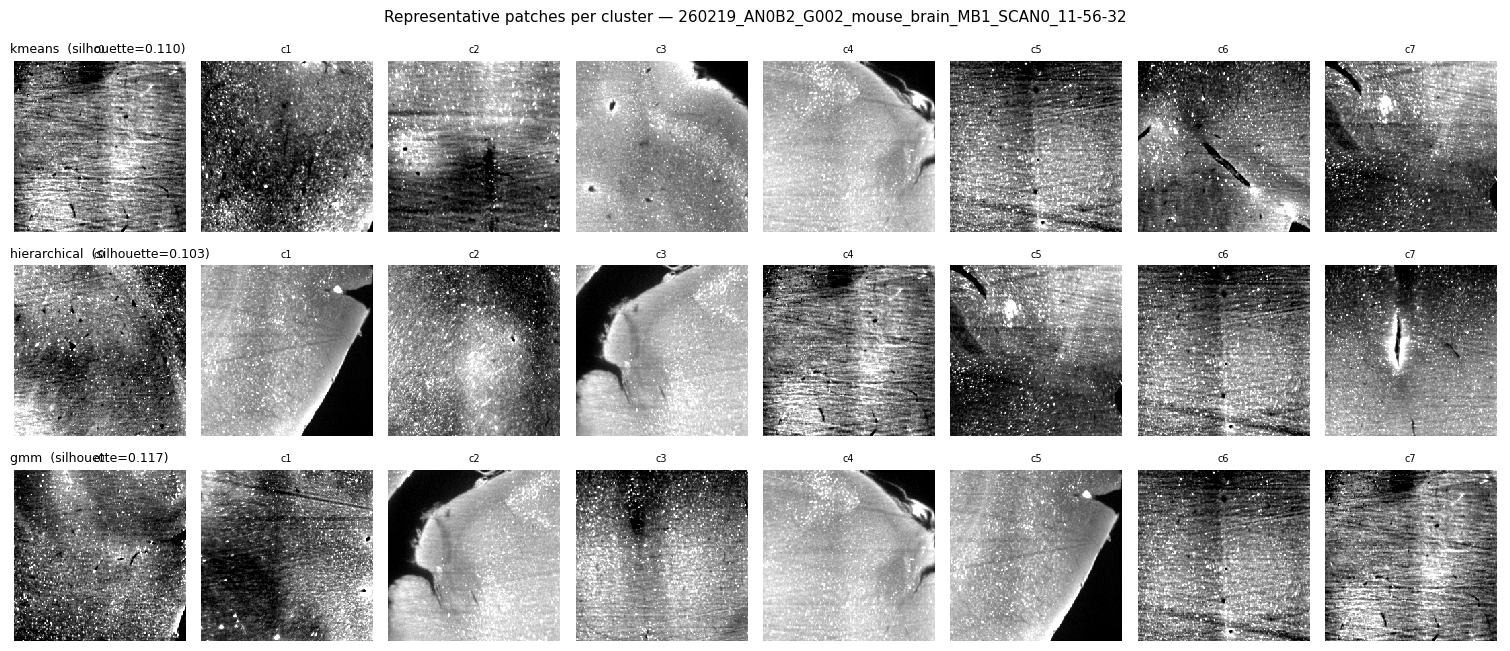

In [12]:
from sklearn.metrics import pairwise_distances_argmin

def get_representatives(result, embeddings, n_clusters):
    """Return one patch index per cluster — the patch closest to the cluster centre."""
    feat = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    if hasattr(result.model, 'cluster_centers_'):   # KMeans
        centres = result.model.cluster_centers_
    elif hasattr(result.model, 'means_'):            # GMM
        centres = result.model.means_
    else:                                            # Hierarchical
        centres = np.vstack([feat[result.labels == c].mean(axis=0) for c in range(n_clusters)])
    return pairwise_distances_argmin(centres, feat)

fig, big_axes = plt.subplots(3, 1, figsize=(N_CLUSTERS * 1.9, 3 * 2.2))
fig.suptitle(f"Representative patches per cluster — {scan_name}", fontsize=11)

for big_ax, method in zip(big_axes, Method):
    r    = results[method]
    reps = get_representatives(r, embeddings, N_CLUSTERS)
    big_ax.set_title(f"{method.value}  (silhouette={r.silhouette:.3f})", loc='left', fontsize=9)
    big_ax.axis('off')

    inner = gridspec.GridSpecFromSubplotSpec(1, N_CLUSTERS, subplot_spec=big_ax.get_subplotspec(), wspace=0.05)
    for c, idx in enumerate(reps):
        ax = fig.add_subplot(inner[c])
        img = patches[idx].astype(np.float32)
        p2, p98 = np.percentile(img, 2), np.percentile(img, 98)
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        ax.imshow(img, cmap='gray', interpolation='nearest')
        ax.set_title(f"c{c}", fontsize=7)
        ax.axis('off')

plt.tight_layout()
plt.show()

## Export for interface

Run the cell below to produce a clean dict that your Streamlit / Dash app can consume directly.
Each method's entry contains labels, UMAP coordinates, silhouette, and representative indices.

In [13]:
interface_data = {}

for method in Method:
    r           = results[method]
    u1, u2, dim = coords[method]
    reps        = get_representatives(r, embeddings, N_CLUSTERS)

    interface_data[method.value] = {
        "labels":          r.labels,
        "n_clusters":      r.n_clusters,
        "silhouette":      r.silhouette,
        "recommended_k":   best_k_per_method.get(method, N_CLUSTERS),  # elbow auto-pick
        "representatives": reps,
        "umap1":           u1,
        "umap2":           u2,
        "dim_method":      dim,
        "proba":           getattr(r, 'proba', None),   # (N, k) for GMM, else None
    }

interface_data['_shared'] = {
    'patches':   patches,
    'metadata':  metadata,
    'scan_name': scan_name,
    'condition': condition,
    'n_clusters': N_CLUSTERS,
}

print("interface_data keys:", list(interface_data.keys()))
for m in Method:
    d = interface_data[m.value]
    print(f"  {m.value:<15} sil={d['silhouette']:.4f}  recommended_k={d['recommended_k']}")

interface_data keys: ['kmeans', 'hierarchical', 'gmm', '_shared']
  kmeans          sil=0.1097  recommended_k=9
  hierarchical    sil=0.1033  recommended_k=5
  gmm             sil=0.1168  recommended_k=10
